# Preprocessing pipeline

**Goal** here is to select a proper window of samples.

Apply **filtering** within the window to interpolate data during blinks

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.interpolate as cwi
from importlib import reload
reload(cwi)
reload(cwpre)
COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = [1]
EXPERIMENTS = [1,2,3,4]

In [14]:
# Load the dataset
eye_df = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print("Loaded eye-tracking data shape:", eye_df.shape)

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
Loaded eye-tracking data shape: (10312, 12)


In [3]:
# Checking the different cl values for subject id
display(eye_df[eye_df["subject_id"] == 21].groupby("task_id")["cl_class"].unique())

KeyError: 'Column not found: cl_class'

## A. Extract window

Extract a proper window for analysis. Also validates invididual methods used for preprocessing.

*A priori* using $T\approx 10s$ consisting of $N=512$ samples seems like a good start.

Thus, inference could be done on a *per second* basis, giving overlapping windows of N~448 samples

In [17]:
N = 600 # Number of samples in the window
offset = 0*300 # Offset in # samples for the start of the window
fs = 60
SUBJECT_ID = 1
TASK_ID = 1

subject_df = eye_df[(eye_df["subject_id"] == SUBJECT_ID) & (eye_df["task_id"] == TASK_ID)].reset_index(drop=True)
print("Extracting a window of {} samples which corresponds to {:.2f} seconds".format(N, N/fs))
# window_df = subject_df.iloc[offset:offset+N].copy()
window_df = subject_df.copy()

window_df['gaze_point_3d_y'].describe()

Extracting a window of 600 samples which corresponds to 10.00 seconds


count    2028.000000
mean      -24.211876
std        20.857401
min      -161.238478
25%       -29.991491
50%       -26.070988
75%       -21.481091
max       162.232531
Name: gaze_point_3d_y, dtype: float64

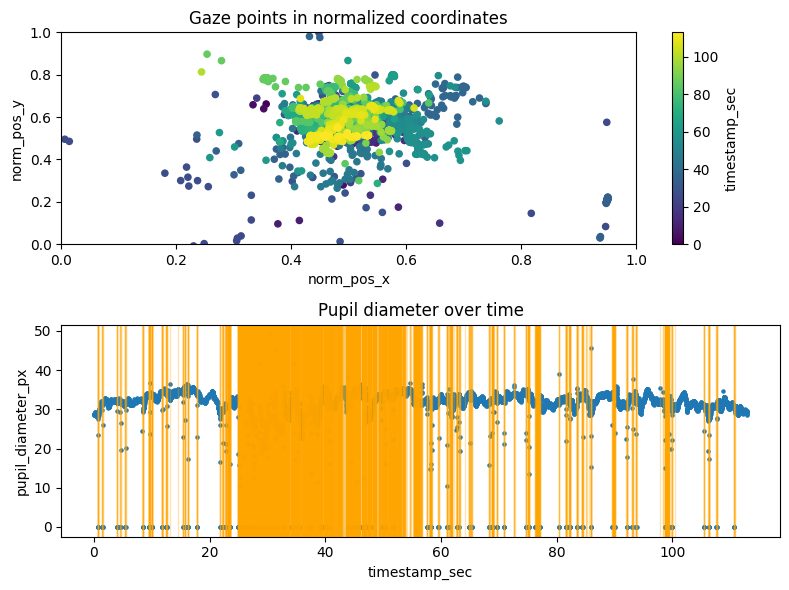

In [22]:
import matplotlib
# Visualize a bit the data in the window
fig = plt.figure(figsize=(8, 6), tight_layout=True)
ax0 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
# Plot gaze data in normalized coordinates
colormap = matplotlib.colormaps['viridis']
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
window_df.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp_sec', colormap=colormap, title="Gaze points in normalized coordinates", ax=ax0)

# Plot (best of the 2 eyes) pupil diameter over time 
# Inverse colormap mapping
window_df.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Pupil diameter over time", ax=ax2, sizes=[5])

# Overlay the blinks as vertical zones
# blink_df['blink_timestamp'] = blink_df['start_timestamp'] - window_df['timestamp_sec'].min() # Align blink timestamps with window timestamps
# blink_df_window = blink_df[(blink_df['blink_timestamp'] >= window_df['timestamp_sec'].min()) & (blink_df['blink_timestamp'] <= window_df['timestamp_sec'].max())]
# if blink_df_window.empty:
#     print("No (official) blinks detected in the current window.")
# for _, row in blink_df_window.iterrows():
#     ax2.axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

# Show low confidence zones
window_df['low_confidence'] = window_df['confidence'] < 0.95
for _, row in window_df[window_df.low_confidence].iterrows():
    ax2.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/240, color='orange', alpha=0.3)

Pipeline goes as follow:
1. Identify gaps and blinks
2. Remove low confidence samples
3. Apply margin to big gaps (> 75ms)
4. Filter pupil data
5. Calculate gaze angles
6. Interpolate gaps < 300ms by using resampling strategy (both pupil & gaze angle)

Detected gaps and blinks in the current window:


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms,is_blink
0,38,45,0.631328,0.748019,116.69,True
1,85,90,1.414818,1.498169,83.35,False
2,236,240,3.931989,3.998668,66.68,False
3,273,277,4.548779,4.615458,66.68,False
4,324,329,5.398949,5.482298,83.35,False
...,...,...,...,...,...,...
196,6024,6024,100.417948,100.417948,0.00,False
197,6329,6333,105.502298,105.568979,66.68,False
198,6375,6382,106.269119,106.385808,116.69,True
199,6457,6462,107.636059,107.719409,83.35,False


Removed 2105 low confidence samples from the window.
Detected pupil diameter outliers in the current window:


,timestamp_sec,pupil_diameter_px,dilation_speed,is_outlier
91,1.514838,26.017300,336.715570,True
92,1.531508,31.630348,336.715570,True
241,4.015339,29.620140,119.891450,True
242,4.032008,31.618731,119.891450,True
271,4.515439,32.050400,165.305913,True
272,4.532108,29.294750,165.305913,True
278,4.632129,26.403011,296.718687,True
279,4.648798,31.349312,296.718687,True
330,5.498969,29.835558,86.925211,True
331,5.515638,31.284601,86.925211,True


Removed 39 pupil diameter outliers from the window.
Removed 278 samples due to low confidence and proximity to detected blinks/gaps.


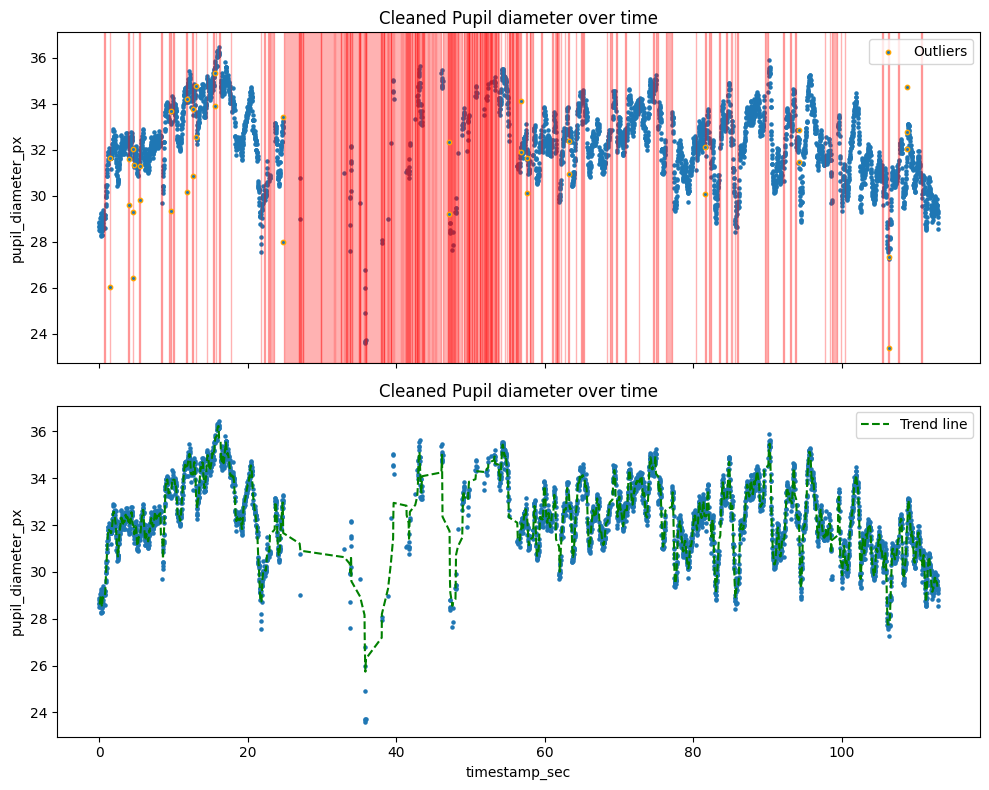

In [23]:
import cognitive_models.gaze_utils as cwgaze
import cognitive_models.pupil_utils as cwpupil
reload(cwgaze)
reload(cwpupil)

window_df_clean = window_df.copy()

CONFIDENCE_THRESHOLD = 0.95
MARGINS = 50 / 1000 # 50 ms margins around detected blinks and gaps
DURATION_THRESHOLD = 75
 
# Detect gaps and blinks in the current window
gaps_df = cwgaze.detect_gaps_and_blinks(window_df_clean, confidence_threshold=CONFIDENCE_THRESHOLD)
print("Detected gaps and blinks in the current window:")
display(gaps_df)

# Remove low confidence samples
n_to_remove = window_df_clean[window_df_clean["confidence"] < CONFIDENCE_THRESHOLD].shape[0]
window_df_clean = window_df_clean[window_df_clean["confidence"] >= CONFIDENCE_THRESHOLD]
print(f"Removed {n_to_remove} low confidence samples from the window.")

# Detect pupil diameter outliers
outliers_df = cwpupil.detect_outliers(window_df_clean, column="pupil_diameter_px", n_multiplier=10)
print("Detected pupil diameter outliers in the current window:")
display(outliers_df[["timestamp_sec", "pupil_diameter_px", "dilation_speed", "is_outlier"]])
window_df_clean = window_df_clean[~window_df_clean["timestamp_sec"].isin(outliers_df["timestamp_sec"])]
print(f"Removed {outliers_df.shape[0]} pupil diameter outliers from the window.")

# Remove samples that are within the margins of detected blinks and gaps
size_before = window_df_clean.shape[0]
for _, row in gaps_df[gaps_df['duration_ms'] >= DURATION_THRESHOLD].iterrows():
    idx_to_drop = window_df_clean[
        (window_df_clean['timestamp_sec'] >= row['start_timestamp'] - MARGINS) &
        (window_df_clean['timestamp_sec'] <= row['stop_timestamp'] + MARGINS)
    ].index
    window_df_clean.drop(idx_to_drop, inplace=True)

size_after = window_df_clean.shape[0]
print(f"Removed {size_before - size_after} samples due to low confidence and proximity to detected blinks/gaps.")

# Before interpolation, plot the pupil diameter with the detected gaps and blinks
fig, axs = plt.subplots(2, 1, figsize=(10, 8), tight_layout=True, sharex=True)
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[0], sizes=[5])
for _, row in gaps_df.iterrows():
    axs[0].axvspan(row['start_timestamp'], row['stop_timestamp'], color='red', alpha=0.3)
outliers_df.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', ax=axs[0], sizes=[10], label="Outliers", edgecolors='orange')
axs[0].legend()

# Plot pupil diameter without outliers
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", ax=axs[1], sizes=[5])
# Show a trend line to see the overall trend of the pupil diameter (using window convolution)
trend_line = np.convolve(window_df_clean["pupil_diameter_px"], np.ones(10)/10, mode='valid')
axs[1].plot(window_df_clean["timestamp_sec"][5:-4], trend_line[:len(window_df_clean)], color='green', label="Trend line", linestyle='--')
axs[1].legend()

After interpolation, we have 1220 interpolated samples and 5577 total samples.


<Axes: title={'center': 'Interpolated Gaze angle delta over time'}, xlabel='timestamp_sec', ylabel='gaze_angle_delta_deg'>

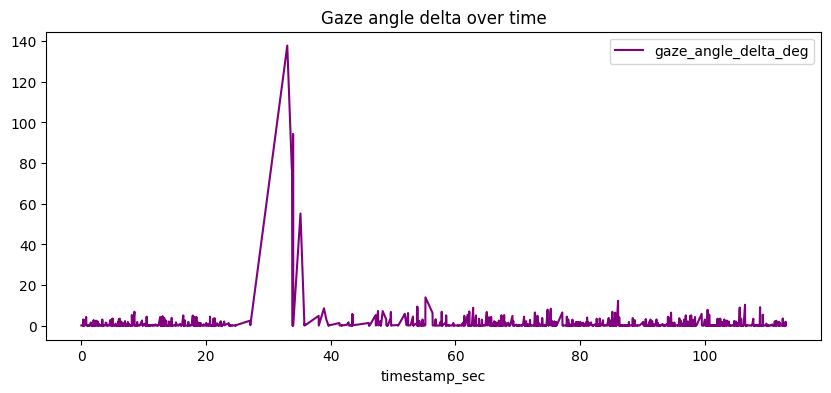

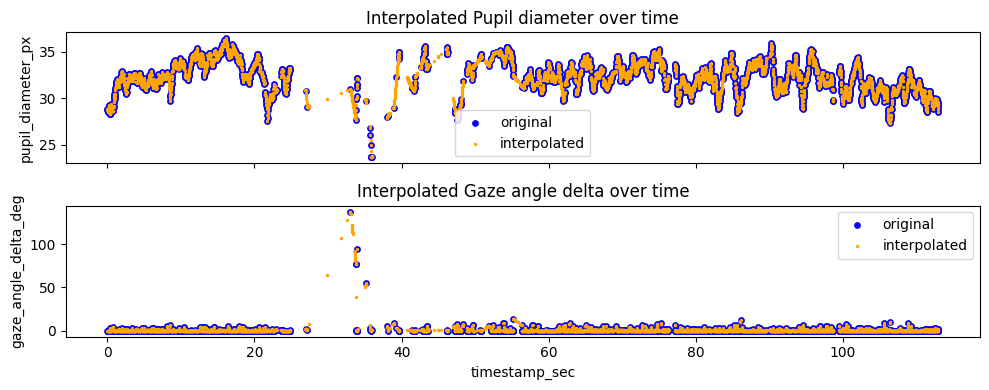

In [24]:
reload(cwi)
# Calculate gaze angles
window_df_clean['gaze_angle_delta_deg'] = cwgaze.calculate_gaze_angular_delta(window_df_clean)
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='line', title="Gaze angle delta over time", color='purple', figsize=(10, 4))

# Only interpolate pupil diameter where gaps are smaller than a threshold
INTERPOLATION_THRESHOLD = 300 # ms
window_pupil_df_interpolated = cwi.interpolate_pupil_data(window_df_clean, gaps_df, column="pupil_diameter_px", max_gap=INTERPOLATION_THRESHOLD)
window_gaze_df_interpolated = cwi.interpolate_gaze_angle(window_df_clean, gaps_df, columns=["gaze_angle_delta_deg", "norm_pos_x", "norm_pos_y"], max_gap=INTERPOLATION_THRESHOLD)
print(f"After interpolation, we have {window_pupil_df_interpolated['is_interpolated'].sum()} interpolated samples and {window_pupil_df_interpolated.shape[0]} total samples.")

fig, axs = plt.subplots(2,1, figsize=(10, 4), tight_layout=True, sharex=True)
window_df_clean.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Cleaned Pupil diameter over time", color='blue', sizes=[15], ax=axs[0], label="original")
window_pupil_df_interpolated.plot("timestamp_sec", "pupil_diameter_px", kind='scatter', title="Interpolated Pupil diameter over time", color='orange', sizes=[2], ax=axs[0], label="interpolated")
axs[0].legend()
window_df_clean.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Cleaned Gaze angle delta over time", color='blue', sizes=[15], ax=axs[1], label="original")
window_gaze_df_interpolated.plot("timestamp_sec", "gaze_angle_delta_deg", kind='scatter', title="Interpolated Gaze angle delta over time", color='orange', sizes=[2], ax=axs[1], label="interpolated")

Found 317 transitions between saccades and fixations
Will mark 8 short fixations as saccades


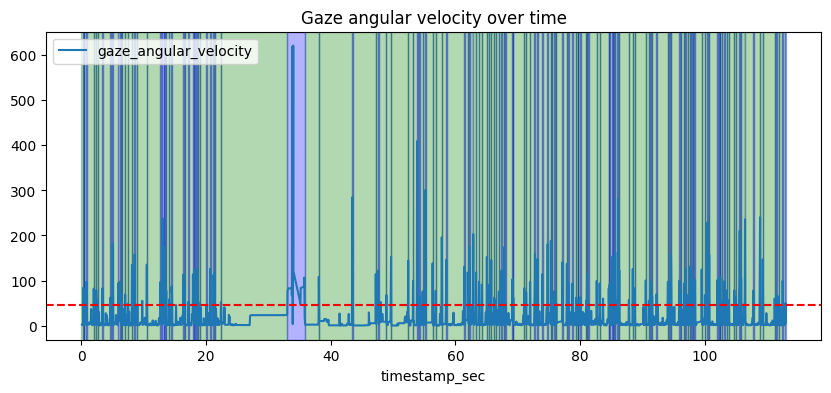

In [25]:
reload(cwgaze)
# Extract required features for the window
window_gaze_df_interpolated['gaze_angular_velocity'] = cwgaze.calculate_angular_velocity(window_gaze_df_interpolated)

window_df, fixations_df, saccades_df = cwgaze.calculate_fixations_saccades(window_gaze_df_interpolated, gaps_df, ivt_threshold=45)

# Plot fixations / saccades zones
fig, ax = plt.subplots(figsize=(10, 4))
window_df.plot("timestamp_sec", "gaze_angular_velocity", kind='line', title="Gaze angular velocity over time", ax=ax)
for _, row in fixations_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)
ax.axhline(45, color='red', linestyle='--', label="IVT threshold")


In [26]:
# Using the preprocessing function
import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
reload(cwpupil)
reload(cwgaze)
reload(cwpre)
reload(cwfeat)

feature_rows = []
for t in range(N, len(subject_df), 300):
    window_df = subject_df.iloc[t-N:t].reset_index(drop=True)
    window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)
    if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
        t_start = window_preprocess_df['timestamp_sec'].min()
        t_end = window_preprocess_df['timestamp_sec'].max()
        print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
        continue

    # Extract features
    features_dict = cwfeat.extract_window_features(
        window_preprocess_df, 
        window_gaze_df, 
        window_pupil_df, 
        window_gaps_df, 
        ivt_threshold=45, 
        min_fixation_duration=55, 
        verbose=False
    )

    feature_rows.append(features_dict)

features_df = pd.DataFrame(feature_rows)
print("Extracted features shape:", features_df.shape)
features_df.head(10)


Skipping window [25.00, 29.99] due to low confidence percentage of 92.67%
Skipping window [30.00, 34.99] due to low confidence percentage of 85.00%
Skipping window [35.00, 39.99] due to low confidence percentage of 69.33%
Skipping window [40.01, 44.99] due to low confidence percentage of 62.33%
Skipping window [45.01, 49.99] due to low confidence percentage of 55.33%
Extracted features shape: (17, 19)


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,saccades_amplitude_std,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2
0,9,492.691111,1216.91,66.68,415.507158,8,78.255676,2.063848,4.212058,0.587064,1.164158,35.423750,50.01,16.67,13.911498,1,0.116690,3.811947,0.003420
1,9,463.055556,916.85,50.01,304.287755,8,85.035332,1.570164,6.195170,0.000580,1.982154,60.428750,266.72,16.67,85.437380,2,0.175035,3.660285,0.001109
2,8,502.183750,2100.42,83.35,654.265266,7,123.871939,1.249254,3.984099,0.020731,1.446818,80.968571,166.70,16.67,64.151401,3,0.116690,4.151419,0.005679
3,9,470.464444,1350.27,66.68,443.385790,8,89.692247,2.031768,4.834668,0.034546,1.843008,60.428750,166.70,16.67,57.703592,2,0.100020,4.815090,0.003321
4,5,883.510000,2383.81,66.68,895.770171,4,101.731776,0.796665,1.911901,0.034320,0.848814,62.512500,116.69,16.67,41.675000,3,0.138917,NaN,0.004031
5,4,1000.200000,3100.62,183.37,1406.418569,3,182.557154,2.092878,3.005465,1.246461,0.881367,66.680000,133.36,33.34,57.746574,10,0.170034,NaN,NaN
6,7,640.604286,1416.95,50.01,491.586697,6,156.353918,4.399036,13.591585,0.024561,5.069988,50.010000,66.68,33.34,18.261070,4,0.145863,NaN,0.000259
7,8,500.100000,1366.94,100.02,371.151583,7,135.265352,3.046388,7.205084,0.020324,2.663597,59.535714,83.35,50.01,13.115886,5,0.113356,4.165833,0.006447
8,11,387.956364,1066.88,50.01,281.035724,10,94.090274,1.576524,4.522542,0.037259,1.521310,38.341000,83.35,16.67,20.865265,2,0.191705,4.012575,0.003001
9,8,550.110000,983.53,166.70,292.964113,7,122.328639,2.853508,6.953111,0.056491,2.872516,50.010000,66.68,16.67,16.670000,0,0.000000,4.012575,0.001275
